In [29]:
from qiskit_aer import AerSimulator
from qiskit import QuantumCircuit, QuantumRegister,ClassicalRegister, transpile

from IPython.display import Math
from qc_workbook.show_state import statevector_expr

import numpy as np
import matplotlib.pyplot as plt

from qiskit.visualization import plot_distribution

from qiskit_aer.primitives import SamplerV2 as Sampler

print("----Start----")
simulator = AerSimulator(method='statevector')
print(simulator.name)

----Start----
aer_simulator_statevector


In [30]:
def get_statevector_array(circuit):
    circuit = circuit.copy()
    circuit.save_statevector()
    circuit = transpile(circuit, backend=simulator)
    job = simulator.run(circuit)
    result = job.result()
    qiskit_statevector = result.data()['statevector']

    return np.asarray(qiskit_statevector)

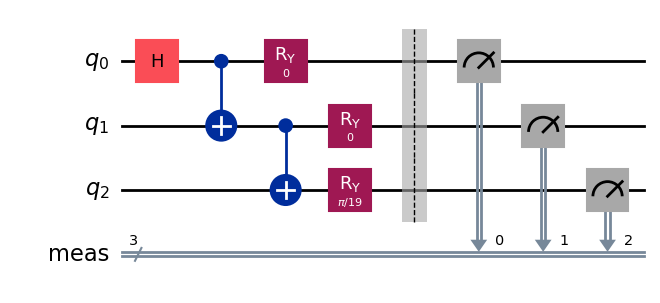

In [31]:
circuits_ghz = []

ntheta = 20
nchi = 20

thetas = np.linspace(0., np.pi, ntheta)
chis = np.linspace(0., np.pi, nchi)

for idx in np.ndindex(ntheta, nchi):
    theta = thetas[idx[0]]
    chi = chis[idx[1]]

    circuit = QuantumCircuit(3, name=f'circuit_{idx[0]}_{idx[1]}')

    circuit.h(0)
    circuit.cx(0,1)
    circuit.cx(1,2)

    circuit.ry(theta,0)
    circuit.ry(theta,1)
    circuit.ry(chi,2)
    
    circuit.measure_all()
    circuits_ghz.append(circuit)

circuits_ghz[0].draw('mpl')    
circuits_ghz[1].draw('mpl')    


In [32]:
sim = AerSimulator()

compiled_circuit = transpile(circuits_ghz, sim, optimization_level=0)

shots = 1000
job = sim.run(compiled_circuit, shots=shots) 
result = job.result()

In [33]:
def counts_ignoring_qubit2(counts, bitstring):
    """Add the counts of cases where qubit C is 0 and 1"""

    return counts.get(f'0{bitstring}', 0) + counts.get(f'1{bitstring}', 0)

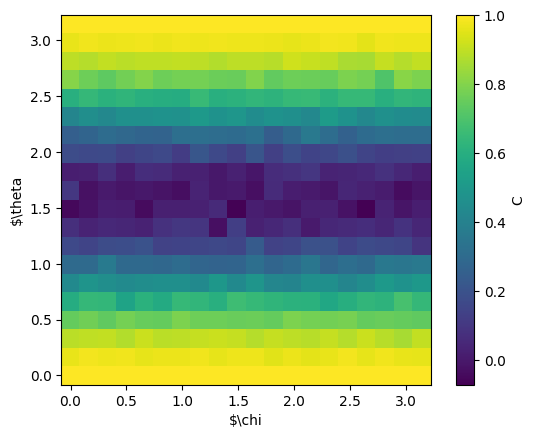

In [34]:
c_values = np.zeros((ntheta, nchi), dtype=float)
for icirc, idx in enumerate(np.ndindex(ntheta, nchi)):
    counts = result.get_counts(icirc)

    n00 = counts_ignoring_qubit2(counts, '00')
    n01 = counts_ignoring_qubit2(counts, '01')
    n10 = counts_ignoring_qubit2(counts, '10')
    n11 = counts_ignoring_qubit2(counts, '11')

    total_shots = n00+n01+n10+n11
    c_values[idx] = (n00+n11-n01-n10) / total_shots

dtheta = (thetas[1] - thetas[0]) * 0.5
dchi = (chis[1] - chis[0]) * 0.5
plt.imshow(c_values[::-1], extent=(chis[0]-dchi, chis[-1]+dchi, thetas[0]-dtheta, thetas[-1]+dtheta) )
plt.xlabel(r'$\chi')
plt.ylabel(r'$\theta')
plt.colorbar(label='C')



In [35]:
max_abs_s = 0.

for ikappa, ilambda, imu, inu in np.ndindex(ntheta, nchi, ntheta, nchi):
    abs_s = abs(c_values[ikappa, ilambda] - c_values[ikappa, inu] + c_values[imu, ilambda] + c_values[imu, inu] )
    max_abs_s = max(abs_s, max_abs_s)

print(f'max |S| = {max_abs_s}')

max |S| = 2.154
